# 02 - Preprocessing & Class Imbalance

Documents the feature engineering pipeline and compares imbalance strategies.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)

from src.preprocess import load_data, preprocess, split_and_save

raw = load_data()
raw.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Run the preprocessing pipeline

In [2]:
df, scaler = preprocess(raw)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Class,Scaled_Amount,Hour,Log_Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,0,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,0,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,0,5.939276
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,0,4.824306
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,0,4.262539


## 2. Before / after: Amount transforms

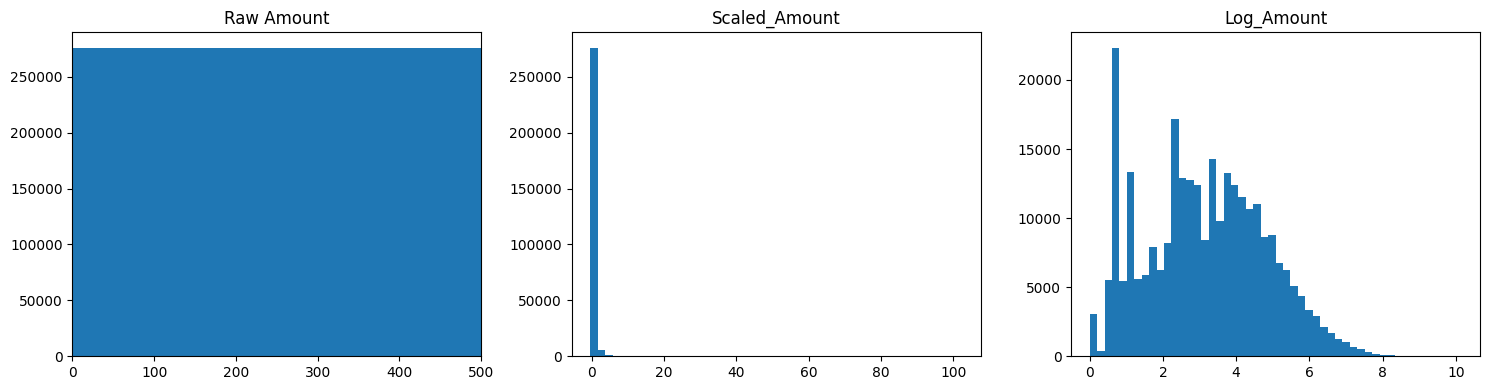

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(raw['Amount'], bins=50); axes[0].set_title('Raw Amount'); axes[0].set_xlim(0, 500)
axes[1].hist(df['Scaled_Amount'], bins=50); axes[1].set_title('Scaled_Amount')
axes[2].hist(df['Log_Amount'], bins=50); axes[2].set_title('Log_Amount')
plt.tight_layout()
plt.show()

## 3. Hour feature distribution

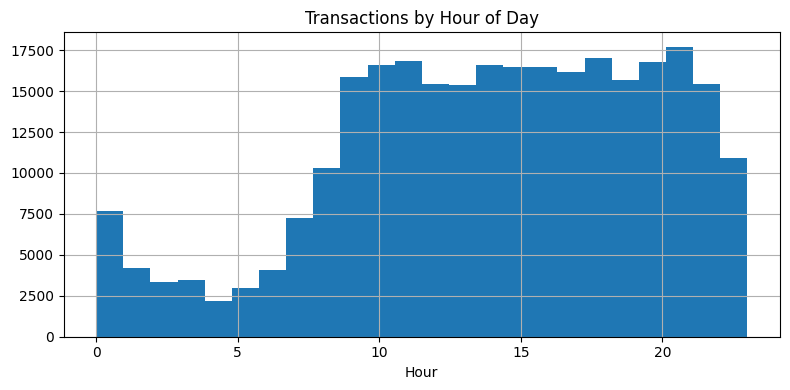

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
df['Hour'].hist(bins=24, ax=ax)
ax.set_title('Transactions by Hour of Day')
ax.set_xlabel('Hour')
plt.tight_layout()
plt.show()

## 4. Final feature list and train/test split

In [5]:
print('Features:', df.drop(columns=['Class']).columns.tolist())
X_train, X_test, y_train, y_test = split_and_save(df)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Fraud rate - Train: {y_train.mean():.4f}, Test: {y_test.mean():.4f}')

Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Scaled_Amount', 'Hour', 'Log_Amount']


Train: (227845, 31), Test: (56962, 31)
Fraud rate - Train: 0.0017, Test: 0.0017


## 5. Handle class imbalance - SMOTE vs Undersampling

In [6]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train, y_train)
print(f'After SMOTE       - Fraud: {int((y_sm==1).sum())}, Legit: {int((y_sm==0).sum())}')

rus = RandomUnderSampler(random_state=42)
X_us, y_us = rus.fit_resample(X_train, y_train)
print(f'After Undersample - Fraud: {int((y_us==1).sum())}, Legit: {int((y_us==0).sum())}')

print('\nClass weights are applied directly inside the models (class_weight="balanced").')

After SMOTE       - Fraud: 227451, Legit: 227451
After Undersample - Fraud: 394, Legit: 394

Class weights are applied directly inside the models (class_weight="balanced").


SMOTE-resampled training data is regenerated inside `src/train.py`, so nothing extra needs saving here. The processed `train.csv`/`test.csv` are already written to `data/processed/`.